# Download libraries 

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Data Loading

In [30]:
df = pd.read_csv('C:/Users/sanad/Downloads/US-pumpkins.csv')


# Data Exploration

In [31]:
print(df.head())
print(df.dtypes)
print(df.describe())

   City Name Type       Package      Variety Sub Variety  Grade     Date  \
0  BALTIMORE  NaN  24 inch bins          NaN         NaN    NaN  4/29/17   
1  BALTIMORE  NaN  24 inch bins          NaN         NaN    NaN   5/6/17   
2  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
3  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN    NaN  9/24/16   
4  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN    NaN  11/5/16   

   Low Price  High Price  Mostly Low  ...  Unit of Sale Quality Condition  \
0      270.0       280.0       270.0  ...           NaN     NaN       NaN   
1      270.0       280.0       270.0  ...           NaN     NaN       NaN   
2      160.0       160.0       160.0  ...           NaN     NaN       NaN   
3      160.0       160.0       160.0  ...           NaN     NaN       NaN   
4       90.0       100.0        90.0  ...           NaN     NaN       NaN   

  Appearance Storage  Crop Repack  Trans Mode  Unnamed: 24  Unnamed: 25  
0     

In [32]:
print(df.isnull().sum())

City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64


# Data Cleaning

In [33]:
data_cleaned = df.dropna(axis=1, how='all').copy()


In [34]:
print("Columns after deleting all empty ones:")
print(data_cleaned.columns)

print(data_cleaned.head())

Columns after deleting all empty ones:
Index(['City Name', 'Type', 'Package', 'Variety', 'Sub Variety', 'Date',
       'Low Price', 'High Price', 'Mostly Low', 'Mostly High', 'Origin',
       'Origin District', 'Item Size', 'Color', 'Unit of Sale', 'Repack',
       'Unnamed: 25'],
      dtype='object')
   City Name Type       Package      Variety Sub Variety     Date  Low Price  \
0  BALTIMORE  NaN  24 inch bins          NaN         NaN  4/29/17      270.0   
1  BALTIMORE  NaN  24 inch bins          NaN         NaN   5/6/17      270.0   
2  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN  9/24/16      160.0   
3  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN  9/24/16      160.0   
4  BALTIMORE  NaN  24 inch bins  HOWDEN TYPE         NaN  11/5/16       90.0   

   High Price  Mostly Low  Mostly High    Origin Origin District Item Size  \
0       280.0       270.0        280.0  MARYLAND             NaN       lge   
1       280.0       270.0        280.0  MARYLAND           

# Encoding

In [35]:
data_encoded = data_cleaned.copy()

text_columns = data_encoded.select_dtypes(include='object').columns

label_encoders = {}
for col in text_columns:
    le = LabelEncoder()
    data_encoded[col] = data_encoded[col].fillna('Unknown')  
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le

print(data_encoded.head())

   City Name  Type  Package  Variety  Sub Variety  Date  Low Price  \
0          1     1        5       10            2    27      270.0   
1          1     1        5       10            2    32      270.0   
2          1     1        5        4            2    49      160.0   
3          1     1        5        4            2    49      160.0   
4          1     1        5        4            2    13       90.0   

   High Price  Mostly Low  Mostly High  Origin  Origin District  Item Size  \
0       280.0       270.0        280.0       8                4          3   
1       280.0       270.0        280.0       8                4          3   
2       160.0       160.0        160.0       4                4          4   
3       160.0       160.0        160.0      23                4          4   
4       100.0        90.0        100.0       8                4          3   

   Color  Unit of Sale  Repack  Unnamed: 25  
0      2             4       0            4  
1      2          

In [36]:
numeric_cols = data_encoded.select_dtypes(include=['number']).columns

for col in numeric_cols:
    median_value = data_encoded[col].median()
    data_encoded[col] = data_encoded[col].fillna(median_value)

print(data_encoded[numeric_cols].isnull().sum())

City Name          0
Type               0
Package            0
Variety            0
Sub Variety        0
Date               0
Low Price          0
High Price         0
Mostly Low         0
Mostly High        0
Origin             0
Origin District    0
Item Size          0
Color              0
Unit of Sale       0
Repack             0
Unnamed: 25        0
dtype: int64


# Feature Engineering

In [37]:
data_encoded['Avg Price'] = (data_encoded['Low Price'] + data_encoded['High Price']) / 2

q1 = data_encoded['Avg Price'].quantile(0.33)
q2 = data_encoded['Avg Price'].quantile(0.66)

def categorize_price_quantile(avg_price):
    if avg_price <= q1:
        return 'Low'
    elif avg_price <= q2:
        return 'Medium'
    else:
        return 'High'

data_encoded['Price Category'] = data_encoded['Avg Price'].apply(categorize_price_quantile)

print(data_encoded['Price Category'].value_counts())

Price Category
Medium    590
High      587
Low       580
Name: count, dtype: int64


In [38]:
X = data_encoded.drop([
    'Price Category',
    'Avg Price',
    'Low Price',
    'High Price',
    'Mostly Low',
    'Mostly High'
], axis=1)

y = data_encoded['Price Category']

# Train/Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(1405, 13) (352, 13)


# Models (Original)
## Model Training (Original Models)

We train four machine learning models:
- Random Forest
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Naive Bayes

These models are trained with default parameters to establish baseline performance.

# Random Forest

In [40]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [41]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.9744


# SVM

In [42]:
X_svm = X.copy()
y_svm = y.copy()

# Split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42
)

# Scaling (IMPORTANT for SVM)
scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_svm)
X_test_svm = scaler.transform(X_test_svm)

In [43]:
svm_model = SVC()
svm_model.fit(X_train_svm, y_train_svm)

SVC()

In [44]:
y_pred_svm = svm_model.predict(X_test_svm)

accuracy_svm = accuracy_score(y_test_svm, y_pred_svm)

print(f"SVM Accuracy: {accuracy_svm:.4f}")

SVM Accuracy: 0.8551


# KNN

In [45]:
X_knn = X.copy()
y_knn = y.copy()
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y_knn, test_size=0.2, random_state=42
)

scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train_knn)
X_test_knn = scaler_knn.transform(X_test_knn)

In [46]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_knn, y_train_knn)

KNeighborsClassifier()

In [47]:
y_pred_knn = knn_model.predict(X_test_knn)

accuracy_knn = accuracy_score(y_test_knn, y_pred_knn)

print(f"KNN Accuracy: {accuracy_knn:.4f}")

KNN Accuracy: 0.9119


# Naive Bayes

In [48]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = X_train_knn, X_test_knn, y_train_knn, y_test_knn

nb_model = GaussianNB()

nb_model.fit(X_train_nb, y_train_nb)

y_pred_nb = nb_model.predict(X_test_nb)
accuracy_nb = accuracy_score(y_test_nb, y_pred_nb)

print(f"Naive Bayes Accuracy: {accuracy_nb:.4f}")

Naive Bayes Accuracy: 0.5256


# Comparison
##  Model Comparison

We compare all models based on their accuracy scores to determine the best performing model.

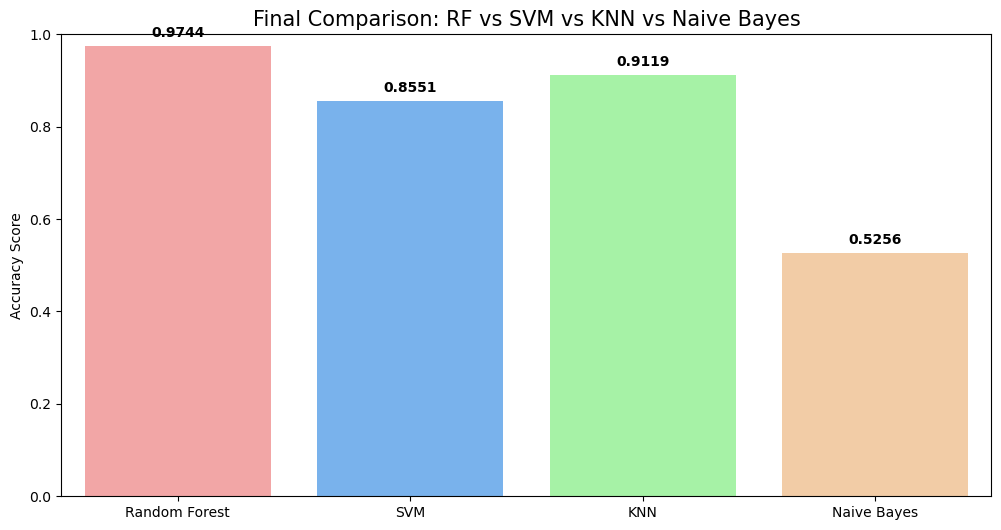

In [49]:
###
acc_scores = {
    'Random Forest': accuracy,
    'SVM': accuracy_svm,
    'KNN': accuracy_knn,
    'Naive Bayes': accuracy_nb
}

plt.figure(figsize=(12, 6))
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']

sns.barplot(
    x=list(acc_scores.keys()), 
    y=list(acc_scores.values()), 
    palette=colors,
    hue=list(acc_scores.keys()),
    legend=False
)

plt.title('Final Comparison: RF vs SVM vs KNN vs Naive Bayes', fontsize=15)
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0)

for i, v in enumerate(acc_scores.values()):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

# Confusion Matrix
## Confusion Matrix Analysis

Confusion matrices are used to evaluate model performance in detail by showing:
- Correct predictions
- Misclassifications

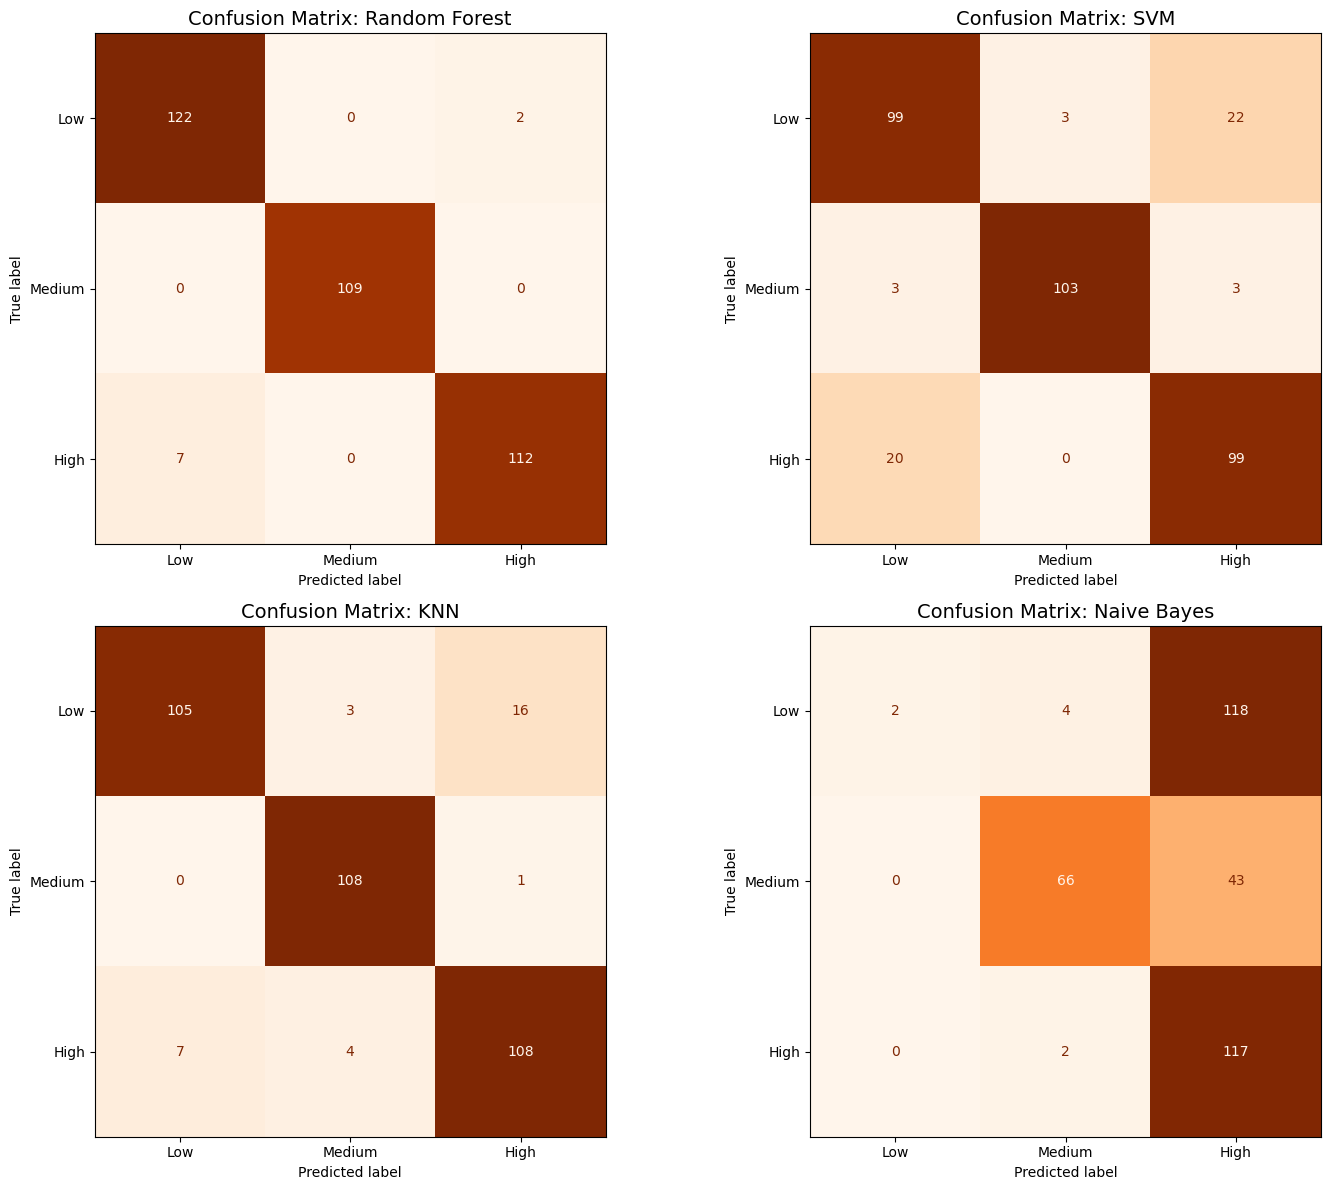

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

price_labels = ['Low', 'Medium', 'High']

models_list = [
    ("Random Forest", rf_model, X_test),
    ("SVM", svm_model, X_test_svm),
    ("KNN", knn_model, X_test_knn),
    ("Naive Bayes", nb_model, X_test_nb)
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, model, x_data) in enumerate(models_list):
    y_p = model.predict(x_data)
    cm = confusion_matrix(y_test, y_p)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=price_labels)
    
    disp.plot(ax=axes[i], cmap='Oranges', colorbar=False) 
    axes[i].set_title(f"Confusion Matrix: {name}", fontsize=14)

plt.tight_layout()
plt.show()

# Tuning Section
## Model Improvement (Hyperparameter Tuning)

In this section, we improve model performance by adjusting key hyperparameters.

Goal:
- Increase accuracy
- Reduce overfitting
- Optimize model behavior

In [51]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)
y_pred_tuned = rf_tuned.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Random Forest (Tuned): {accuracy_tuned:.4f}")

Random Forest (Tuned): 0.9659


# After the SVM optimization

In [52]:
svm_tuned = SVC(kernel='rbf', C=10, gamma=0.1)
svm_tuned.fit(X_train_svm, y_train_svm)
y_pred_svm_tuned = svm_tuned.predict(X_test_svm)

print("SVM (Tuned):", accuracy_score(y_test_svm, y_pred_svm_tuned))

SVM (Tuned): 0.9204545454545454


# After the KNN optimization

In [53]:
knn_tuned = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn_tuned.fit(X_train_knn, y_train_knn)
y_pred_knn_tuned = knn_tuned.predict(X_test_knn)

print("KNN (Tuned):", accuracy_score(y_test_knn, y_pred_knn_tuned))

KNN (Tuned): 0.9630681818181818


# After the NB optimization

In [54]:
nb_tuned = GaussianNB(var_smoothing=1e-8)
nb_tuned.fit(X_train_nb, y_train_nb)
y_pred_nb_tuned = nb_tuned.predict(X_test_nb)

print("NB (Tuned):", accuracy_score(y_test_nb, y_pred_nb_tuned))

NB (Tuned): 0.53125


## Final Comparison After Hyperparameter Tuning

In this section, we compare the performance of all models after applying hyperparameter tuning.

We use the best version of each model to determine which one performs best.

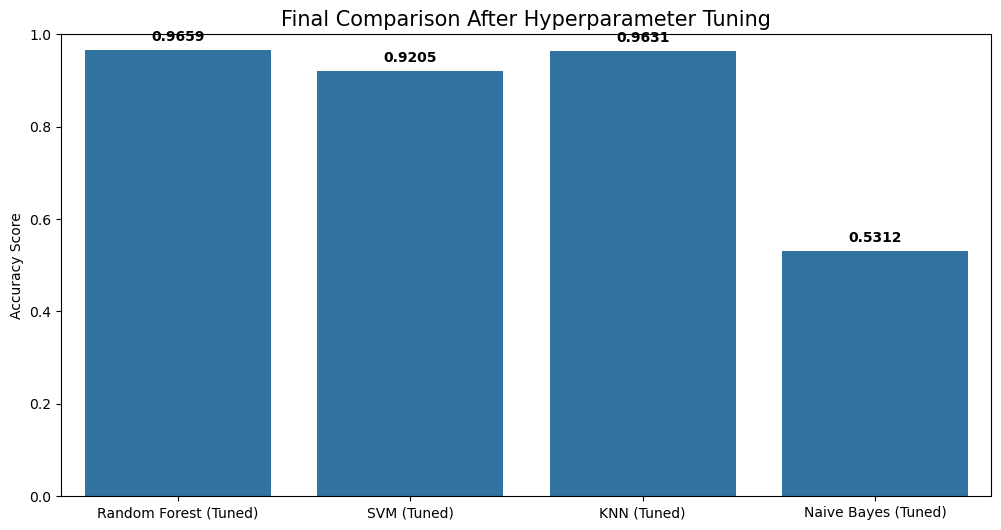

In [56]:
acc_scores_tuned = {
    'Random Forest (Tuned)': accuracy_tuned,  
    'SVM (Tuned)': accuracy_score(y_test_svm, y_pred_svm_tuned),
    'KNN (Tuned)': accuracy_score(y_test_knn, y_pred_knn_tuned),
    'Naive Bayes (Tuned)': accuracy_score(y_test_nb, y_pred_nb_tuned)
}

plt.figure(figsize=(12, 6))

sns.barplot(
    x=list(acc_scores_tuned.keys()), 
    y=list(acc_scores_tuned.values())
)

plt.title('Final Comparison After Hyperparameter Tuning', fontsize=15)
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0)

for i, v in enumerate(acc_scores_tuned.values()):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()